# Lab 02 — Photometric / Point Transformations (AI-4002)
**Syllabus (no manual):** Log · Gamma (Power-law) · Piecewise (contrast stretching, thresholding, intensity slicing, bit-plane slicing) · Histogram (equalization, CLAHE) + colormaps, color balance, fusion, video.

| Section | What's inside |
|---|---|
| 0 | Setup — creates sample X-ray, CT/MRI pair and echo video in `data/` |
| A | Theory demos: negative, log, gamma, contrast stretching, thresholding, intensity slicing, bit-plane slicing, histogram equalization/CLAHE, transformation curves |
| B | **Task 1** Chest X-ray enhancement |
| C | **Task 2** CT + MRI fusion |
| D | **Task 3** Real-time echocardiogram video pipeline |

> All point transforms: **s = T(r)** — new value depends only on the old value of the same pixel.

## 0. Setup — sample data (replace with Kaggle files in `data/`)

In [1]:
import os, cv2, numpy as np
from skimage import data
os.makedirs('data', exist_ok=True); os.makedirs('output', exist_ok=True)

# Underexposed "X-ray" stand-in (dark, low contrast)
if not os.path.exists('data/sample_xray.png'):
    xr = data.camera().astype(np.float32)
    xr = (xr / 255.0) ** 2.2 * 90            # push everything dark -> underexposed
    cv2.imwrite('data/sample_xray.png', xr.astype(np.uint8))

# CT / MRI "heart" phantom pair (same geometry, different contrast)
if not os.path.exists('data/ct.png'):
    yy, xx = np.mgrid[0:256, 0:256]
    def ell(cx, cy, a, b): return ((xx-cx)/a)**2 + ((yy-cy)/b)**2 <= 1
    ct = np.full((256, 256), 20, np.float32)
    ct[ell(128,128,100,85)] = 90; ct[ell(110,120,45,40)] = 160; ct[ell(155,140,30,28)] = 200; ct[ell(128,128,100,85) & ~ell(128,128,92,77)] = 230
    mri = np.full((256, 256), 10, np.float32)
    mri[ell(128,128,100,85)] = 120; mri[ell(110,120,45,40)] = 60; mri[ell(155,140,30,28)] = 180
    mri += 25*np.sin(xx/7.0)*np.cos(yy/9.0) * ell(128,128,100,85)       # soft-tissue texture
    mri = cv2.GaussianBlur(mri, (9, 9), 0)                               # MRI: softer edges
    cv2.imwrite('data/ct.png', np.clip(ct*0.7, 0, 255).astype(np.uint8))  # a bit dark
    cv2.imwrite('data/mri.png', np.clip(mri*0.8, 0, 255).astype(np.uint8))

# Short noisy "echocardiogram" video (beating ellipse + speckle + bright backscatter)
if not os.path.exists('data/echo.mp4'):
    out = cv2.VideoWriter('data/echo.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 15, (200, 200), True)
    rng = np.random.default_rng(0)
    for t in range(45):
        f = np.full((200, 200), 40, np.float32)
        r = 50 + 12*np.sin(t/3)
        cv2.ellipse(f, (100, 100), (int(r), int(r*0.8)), 0, 0, 360, 110, 6)   # heart wall
        cv2.ellipse(f, (100, 100), (int(r-8), int(r*0.8-8)), 0, 0, 360, 15, -1)  # dark chamber
        f += rng.normal(0, 18, f.shape)                                    # speckle noise
        f[rng.random(f.shape) > 0.995] = 255                                # white backscatter
        f = np.clip(f*0.6, 0, 255).astype(np.uint8)                         # murky / low contrast
        out.write(cv2.cvtColor(f, cv2.COLOR_GRAY2BGR))
    out.release()
print(os.listdir('data'))

['mri.png', 'sample_xray.png', 'ct.png', 'echo.mp4']


# A. Theory demos
## A1. Negative, Log and Gamma
| Transform | Formula | Effect |
|---|---|---|
| Negative | s = (L−1) − r = 255 − r | inverts; reveals detail in dark regions |
| Log | s = c·log(1 + r),  c = 255 / log(1 + max r) | **expands darks, compresses brights** |
| Inverse log | s = c·(e^r − 1) style | expands brights, compresses darks |
| Gamma | s = c·r^γ (r normalised 0–1) | γ<1 brighten, γ>1 darken, γ=1 identity |

log constant c = 56.53


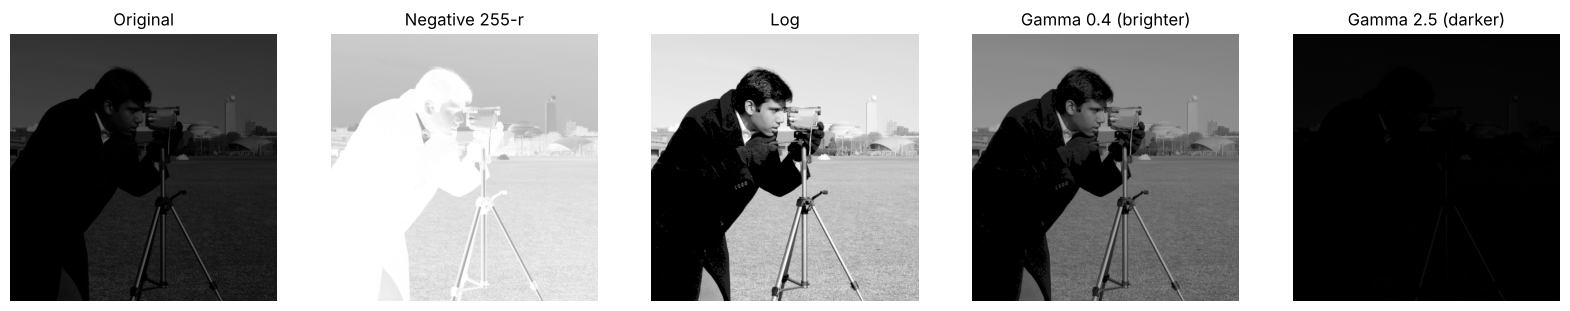

In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt
gray = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)
if gray is None: raise FileNotFoundError('data/sample_xray.png')

negative = 255 - gray

g = gray.astype(np.float32)                    # float first! (avoid uint8 overflow, log needs decimals)
c = 255 / np.log(1 + g.max())                  # scale so brightest pixel -> 255
log_img = np.uint8(c * np.log(1 + g))

def gamma_correct(img, gamma):
    r = img / 255.0                            # 1. normalise to 0–1
    s = np.power(r, gamma)                     # 2. apply power
    return np.uint8(s * 255)                   # 3. back to 0–255

g04, g25 = gamma_correct(gray, 0.4), gamma_correct(gray, 2.5)
print(f'log constant c = {c:.2f}')

imgs = [gray, negative, log_img, g04, g25]
titles = ['Original', 'Negative 255-r', 'Log', 'Gamma 0.4 (brighter)', 'Gamma 2.5 (darker)']
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for a, im, t in zip(ax, imgs, titles): a.imshow(im, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.show()

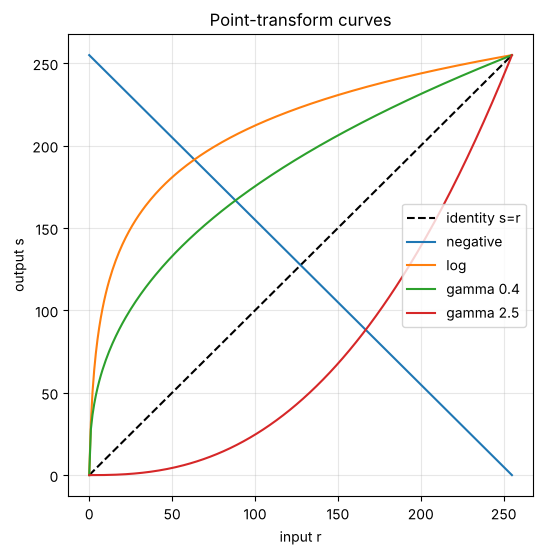

In [3]:
# Transformation curves: above diagonal = brighter, below = darker, steep = more contrast
r = np.arange(256)
plt.figure(figsize=(6, 6))
plt.plot(r, r, 'k--', label='identity s=r')
plt.plot(r, 255 - r, label='negative')
plt.plot(r, 255/np.log(256)*np.log(1 + r), label='log')
for gm in [0.4, 2.5]: plt.plot(r, 255*(r/255)**gm, label=f'gamma {gm}')
plt.xlabel('input r'); plt.ylabel('output s'); plt.legend(); plt.title('Point-transform curves'); plt.grid(alpha=.3)
plt.show()

In [4]:
# Faster gamma for video: a Look-Up Table (computed once for all 256 values)
def gamma_lut(gamma):
    return np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype('uint8')
fast = cv2.LUT(gray, gamma_lut(0.4))
print('LUT result equals direct result:', np.array_equal(fast, gamma_correct(gray, 0.4)) or 'tiny rounding diff')

LUT result equals direct result: True


## A2. Piecewise-linear transforms
* **Contrast stretching:** s = (r − r_min)/(r_max − r_min) × 255. (r1=r2, s1=0, s2=255 ⇒ thresholding)
* **Thresholding:** step function.
* **Intensity-level slicing:** highlight band [A, B] — *binary* (rest → 0) or *preserve background* (rest unchanged).
* **Bit-plane slicing:** plane k = (pixel >> k) & 1. MSB (bit 7) = most visual info, LSB (bit 0) ≈ noise.

input range: 0 90 -> output range: 0 255


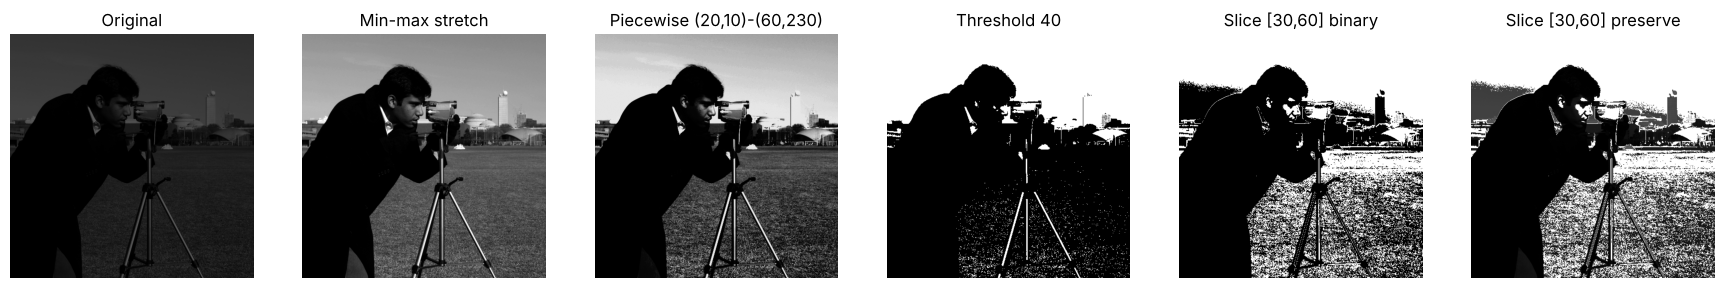

In [5]:
r_min, r_max = int(gray.min()), int(gray.max())
stretched = ((gray.astype(np.float32) - r_min) / (r_max - r_min) * 255).astype(np.uint8)
stretched_cv = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)          # same thing in one call
print('input range:', r_min, r_max, '-> output range:', stretched.min(), stretched.max())

# Piecewise with control points (r1,s1),(r2,s2)
def piecewise(img, r1, s1, r2, s2):
    return np.interp(img, [0, r1, r2, 255], [0, s1, s2, 255]).astype(np.uint8)
pw = piecewise(gray, 20, 10, 60, 230)

_, thresh = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY)

A, B = 30, 60
slice_binary   = np.where((gray >= A) & (gray <= B), 255, 0).astype(np.uint8)
slice_preserve = np.where((gray >= A) & (gray <= B), 255, gray).astype(np.uint8)

fig, ax = plt.subplots(1, 6, figsize=(22, 4))
for a, im, t in zip(ax, [gray, stretched, pw, thresh, slice_binary, slice_preserve],
                     ['Original', 'Min-max stretch', 'Piecewise (20,10)-(60,230)', 'Threshold 40', 'Slice [30,60] binary', 'Slice [30,60] preserve']):
    a.imshow(im, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.show()

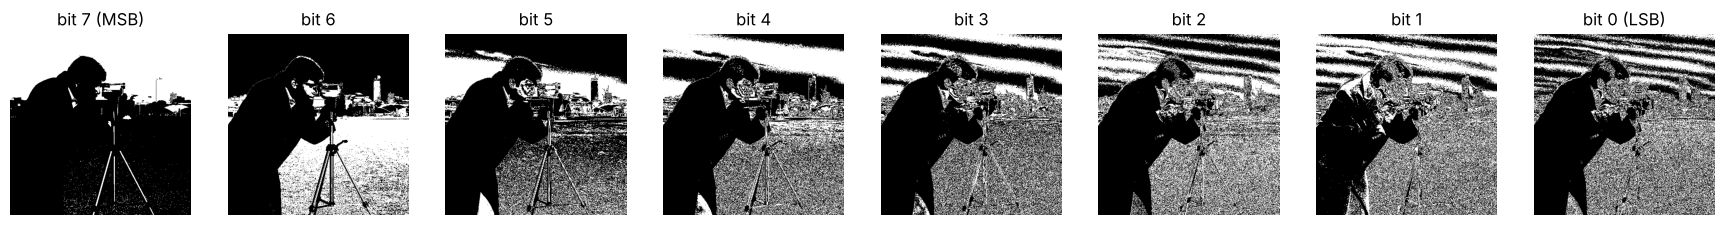

max abs error keeping top-4 planes: 15


In [6]:
# Bit-plane slicing (use the stretched image so all planes have content)
fig, ax = plt.subplots(1, 8, figsize=(22, 3))
for k in range(8):
    plane = ((stretched >> k) & 1) * 255
    ax[7 - k].imshow(plane, cmap='gray'); ax[7 - k].set_title(f'bit {k}' + (' (MSB)' if k == 7 else ' (LSB)' if k == 0 else '')); ax[7 - k].axis('off')
plt.show()
top4 = stretched & 0b11110000            # keep only 4 most significant planes (compression idea)
print('max abs error keeping top-4 planes:', int(np.abs(stretched.astype(int) - top4).max()))

## A3. Histogram processing
* Histogram = count of pixels per intensity. Left = dark, right = bright, narrow = low contrast.
* **Equalization:** s_k = round((L−1) · CDF(r_k)) — spreads intensities over 0–255 → higher contrast. `cv2.equalizeHist` (8-bit, 1 channel).
* **CLAHE:** local (tile-wise) equalization with a clip limit → avoids over-amplifying noise.

manual vs cv2 max difference: 0


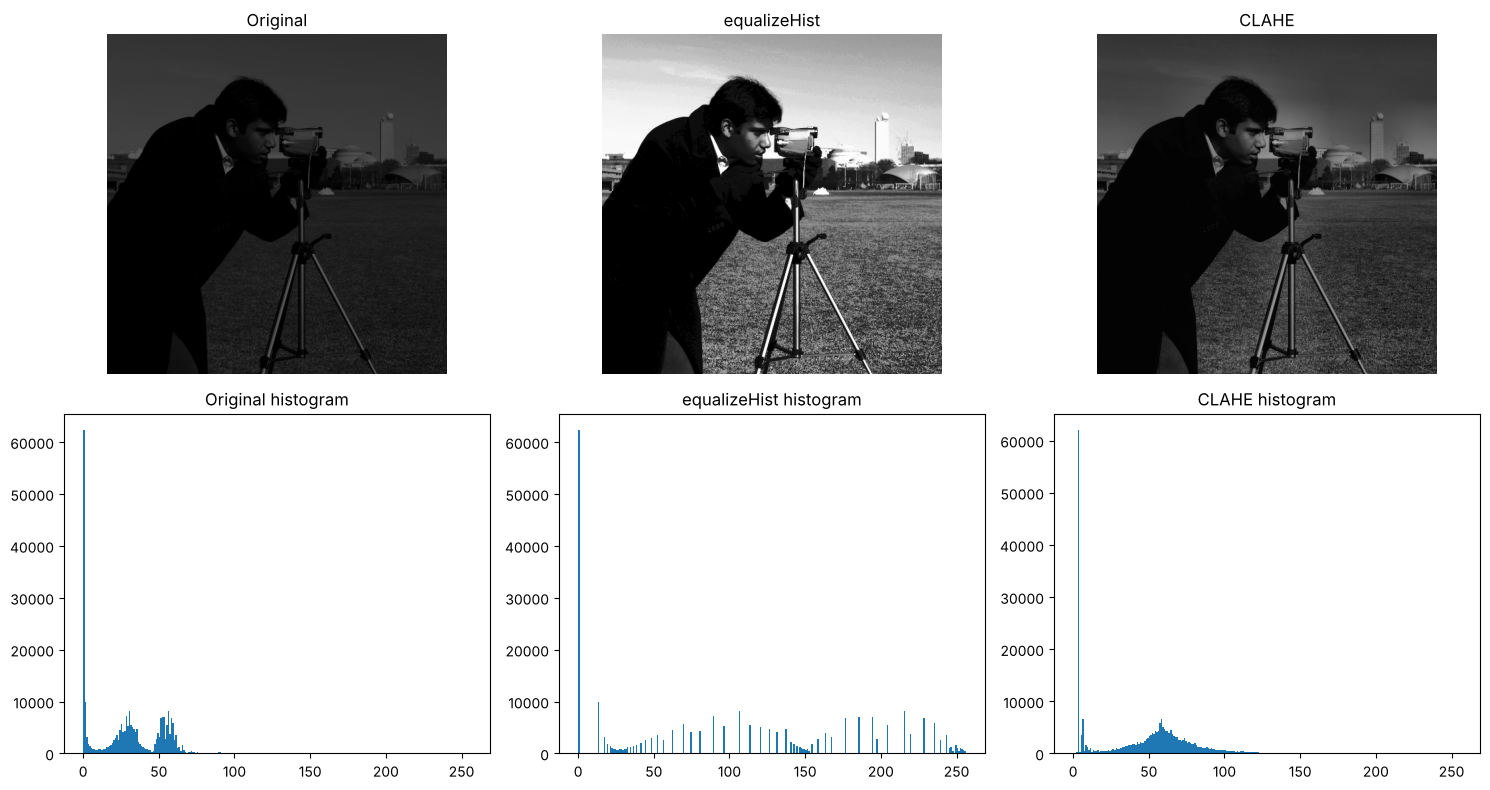

In [7]:
eq = cv2.equalizeHist(gray)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

# Manual equalization (to understand the formula)
hist = np.bincount(gray.ravel(), minlength=256)     # h(r_k)
cdf = hist.cumsum()                                   # running total
cdf_min = cdf[cdf > 0].min()
# textbook: s_k = (L-1) * CDF(r_k);  OpenCV version subtracts cdf_min so the darkest level maps to 0
manual_eq = np.round((cdf[gray] - cdf_min) / (cdf[-1] - cdf_min) * 255).astype(np.uint8)
print('manual vs cv2 max difference:', int(np.abs(manual_eq.astype(int) - eq.astype(int)).max()))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for i, (im, t) in enumerate([(gray, 'Original'), (eq, 'equalizeHist'), (clahe, 'CLAHE')]):
    ax[0, i].imshow(im, cmap='gray', vmin=0, vmax=255); ax[0, i].set_title(t); ax[0, i].axis('off')
    ax[1, i].hist(im.ravel(), bins=256, range=(0, 256)); ax[1, i].set_title(f'{t} histogram')
plt.tight_layout(); plt.show()

# B. Task 1 — Diagnostic Enhancement of Chest X-Rays
Pipeline: Load → Histogram Equalization → COLORMAP_JET → Color balance → Threshold (densest tissue) → Log → Gamma (γ<1).

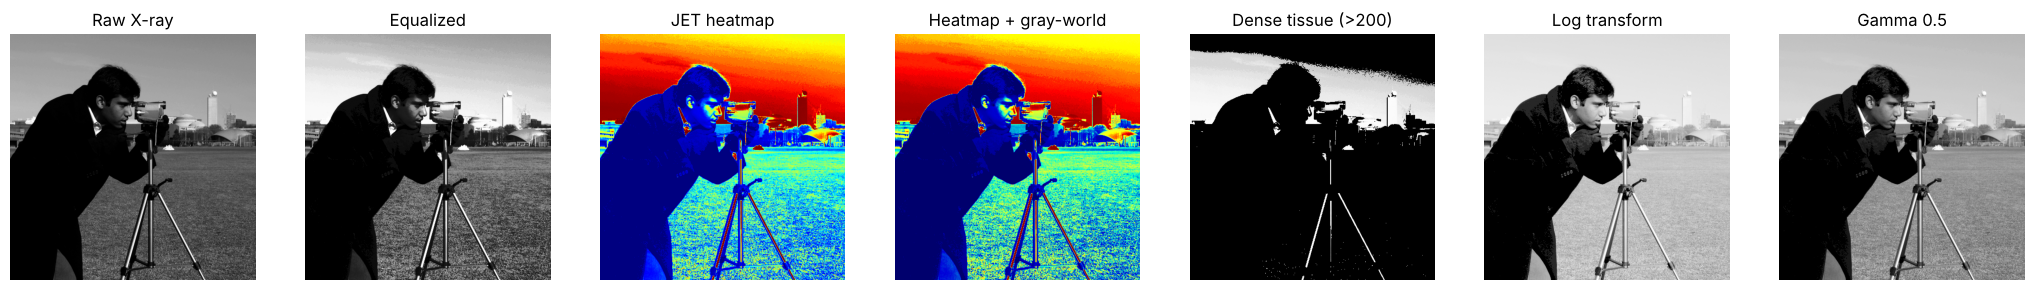

In [8]:
xray = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)     # relative path, single channel
if xray is None: raise FileNotFoundError('data/sample_xray.png')

# 1) Contrast enhancement
xray_eq = cv2.equalizeHist(xray)

# 2) Color mapping: intensity -> color spectrum (blue=low ... red=high)
heat = cv2.applyColorMap(xray_eq, cv2.COLORMAP_JET)                 # output is BGR, 3 channels

# 3) Color balance (Gray-World): scale each channel so all channel means become equal
def gray_world(bgr):
    f = bgr.astype(np.float32)
    means = f.reshape(-1, 3).mean(axis=0)                           # mean of B, G, R
    f *= means.mean() / (means + 1e-6)                              # per-channel gain
    return np.clip(f, 0, 255).astype(np.uint8)
heat_bal = gray_world(heat)

# 4) Color filtering (thresholding): keep only densest (brightest) tissue
T = 200
_, dense_mask = cv2.threshold(xray_eq, T, 255, cv2.THRESH_BINARY)
dense_only = cv2.bitwise_and(xray_eq, xray_eq, mask=dense_mask)

# 5) Log transform on RAW underexposed image -> expands dark regions (ribcage edges)
f = xray.astype(np.float32)
xray_log = np.uint8(255 / np.log(1 + f.max()) * np.log(1 + f))

# 6) Power-law with gamma < 1 -> brightens midtones, compresses harsh bright bones
xray_gamma = np.uint8(np.power(xray / 255.0, 0.5) * 255)

panels = [(xray, 'Raw X-ray'), (xray_eq, 'Equalized'), (cv2.cvtColor(heat, cv2.COLOR_BGR2RGB), 'JET heatmap'),
          (cv2.cvtColor(heat_bal, cv2.COLOR_BGR2RGB), 'Heatmap + gray-world'), (dense_only, f'Dense tissue (>{T})'),
          (xray_log, 'Log transform'), (xray_gamma, 'Gamma 0.5')]
fig, ax = plt.subplots(1, 7, figsize=(26, 4))
for a, (im, t) in zip(ax, panels):
    a.imshow(im, cmap='gray' if im.ndim == 2 else None); a.set_title(t); a.axis('off')
plt.show()
for name, im in [('equalized', xray_eq), ('heatmap', heat), ('heatmap_balanced', heat_bal), ('dense', dense_only), ('log', xray_log), ('gamma', xray_gamma)]:
    cv2.imwrite(f'output/task1_{name}.png', im)

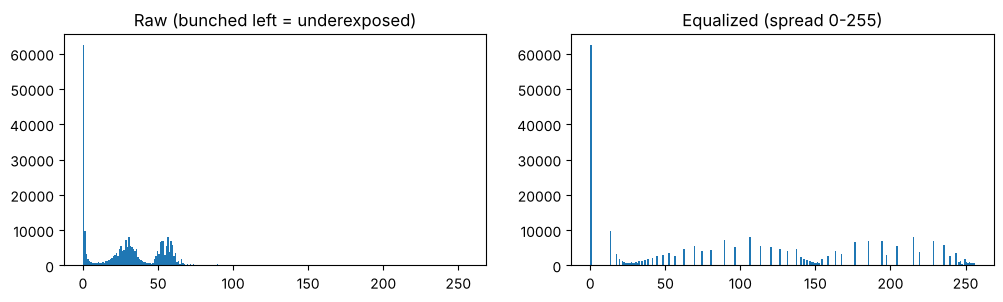

In [9]:
# Document the change: compare histograms raw vs equalized
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].hist(xray.ravel(), bins=256, range=(0, 256)); ax[0].set_title('Raw (bunched left = underexposed)')
ax[1].hist(xray_eq.ravel(), bins=256, range=(0, 256)); ax[1].set_title('Equalized (spread 0-255)')
plt.show()

**Notes to write:**
* Equalization redistributes intensities using the CDF, so hidden lung structures become visible.
* JET maps small intensity differences to clearly different hues — the eye separates colors better than gray levels, so subtle fluid boundaries stand out.
* Gray-world balance removes the artificial blue/red cast JET introduces (channel means equalised).
* Log expands dark values (faint ribcage edges); γ<1 lifts midtones while compressing the bright bone range.

# C. Task 2 — Multi-Modal Cardiac Image Fusion
Pipeline: load CT + MRI → equalize each → colormap → `addWeighted` (CT heavier) → log + gamma → side-by-side.

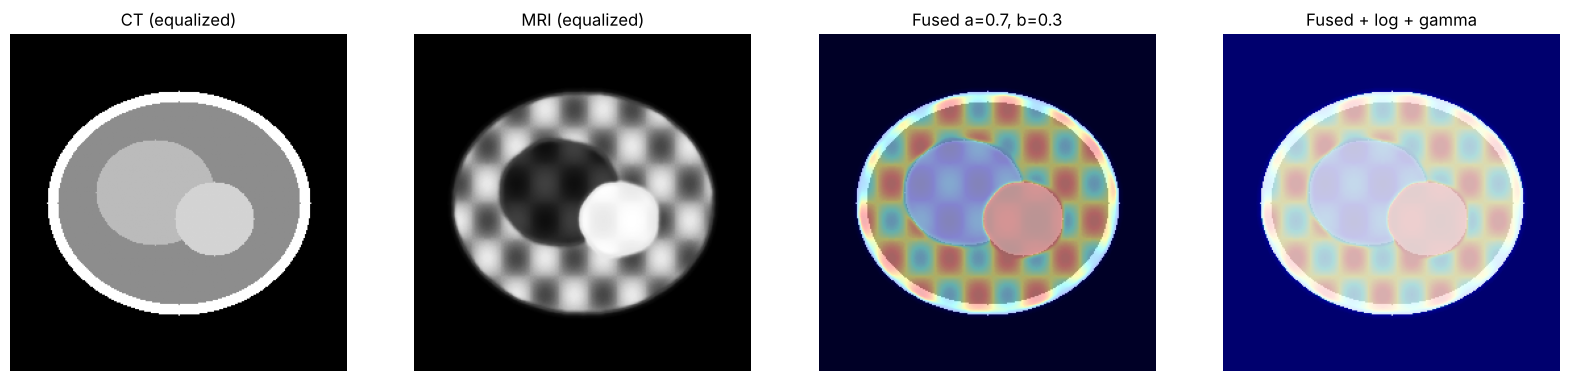

CT     contrast(std)=  90.5  edge sharpness(Laplacian var)=   2850.7
MRI    contrast(std)=  80.7  edge sharpness(Laplacian var)=     58.6
Fused  contrast(std)=  98.2  edge sharpness(Laplacian var)=   1477.8


In [10]:
ct  = cv2.imread('data/ct.png',  cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('data/mri.png', cv2.IMREAD_GRAYSCALE)
if ct is None or mri is None: raise FileNotFoundError('need data/ct.png and data/mri.png')
mri = cv2.resize(mri, (ct.shape[1], ct.shape[0]))            # same size required (w, h)

ct_eq, mri_eq = cv2.equalizeHist(ct), cv2.equalizeHist(mri)   # maximize dynamic range independently

ct_col  = cv2.cvtColor(ct_eq, cv2.COLOR_GRAY2BGR)              # CT kept gray (structure)
mri_col = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)          # MRI as heatmap (soft tissue)

alpha, beta = 0.7, 0.3                                          # CT heavier -> sharp anatomical edges
fused = cv2.addWeighted(ct_col, alpha, mri_col, beta, 0)        # fused = CT*0.7 + MRI*0.3

# Log then gamma so nothing is crushed to black or blown to white
f = fused.astype(np.float32)
fused_log = np.uint8(255 / np.log(1 + f.max()) * np.log(1 + f))
fused_final = np.uint8(np.power(fused_log / 255.0, 2.0) * 255)  # gamma>1 restores contrast after log lifted everything

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, im, t in zip(ax, [ct_eq, mri_eq, cv2.cvtColor(fused, cv2.COLOR_BGR2RGB), cv2.cvtColor(fused_final, cv2.COLOR_BGR2RGB)],
                    ['CT (equalized)', 'MRI (equalized)', f'Fused a={alpha}, b={beta}', 'Fused + log + gamma']):
    a.imshow(im, cmap='gray' if im.ndim == 2 else None); a.set_title(t); a.axis('off')
plt.show()
cv2.imwrite('output/task2_fused.png', fused_final)

# "Mathematical" validation: edge strength + contrast of each
def stats(im):
    g = im if im.ndim == 2 else cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    return g.std(), cv2.Laplacian(g, cv2.CV_64F).var()
for name, im in [('CT', ct_eq), ('MRI', mri_eq), ('Fused', fused_final)]:
    s, sharp = stats(im); print(f'{name:6s} contrast(std)={s:6.1f}  edge sharpness(Laplacian var)={sharp:9.1f}')

**Weighting logic:** CT shows structural boundaries, so it gets the larger α (0.7) to keep edges; MRI gets β = 0.3 to add soft-tissue variation without blurring edges. α + β = 1 keeps overall brightness unchanged.

# D. Task 3 — Real-Time Echocardiogram Video Analysis
`cv2.VideoCapture` → `while` loop → per frame: equalize → JET → color balance → log → power-law (γ>1 suppresses white backscatter) → `hconcat` raw | enhanced → `cv2.imshow`.

Set `SHOW_WINDOW = True` on your own laptop (opens an OpenCV window, press **q** to quit). In a notebook/headless run it saves frames instead.

frames processed: 45


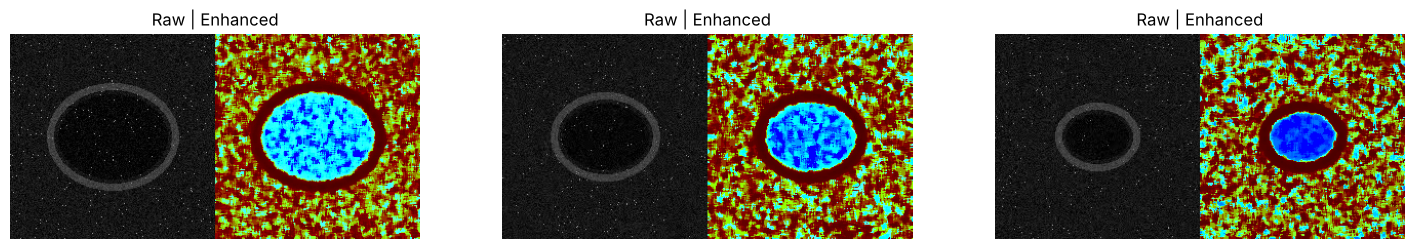

In [11]:
SHOW_WINDOW = False                     # True on your machine for live cv2.imshow window

def enhance_frame(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 5)                                  # remove speckle first (else equalization amplifies it)
    eq = cv2.equalizeHist(gray)                                     # fight murky contrast
    f = eq.astype(np.float32)
    log = np.uint8(255 / np.log(1 + f.max()) * np.log(1 + f))       # reveal dark chambers
    pw = np.uint8(np.power(log / 255.0, 2.0) * 255)                 # gamma>1 suppresses bright backscatter
    heat = cv2.applyColorMap(pw, cv2.COLORMAP_JET)                  # highlight flow intensities
    return gray_world(heat)                                         # color balance (from Task 1)

cap = cv2.VideoCapture('data/echo.mp4')          # file instead of webcam (0)
if not cap.isOpened(): raise FileNotFoundError('data/echo.mp4')
saved, n = [], 0
while True:
    ret, frame = cap.read()                      # ret=False when video ends
    if not ret: break
    enhanced = enhance_frame(frame)
    raw3 = cv2.cvtColor(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)  # both must be 3-channel, same height
    monitor = cv2.hconcat([raw3, enhanced])      # side-by-side (np.hstack also works)
    n += 1
    if SHOW_WINDOW:
        cv2.imshow('Raw | Enhanced', monitor)
        if cv2.waitKey(30) & 0xFF == ord('q'): break
    elif n in (5, 20, 35):
        saved.append(monitor); cv2.imwrite(f'output/task3_frame{n}.png', monitor)
cap.release(); cv2.destroyAllWindows()
print('frames processed:', n)

fig, ax = plt.subplots(1, len(saved), figsize=(18, 4))
for a, m in zip(ax, saved): a.imshow(cv2.cvtColor(m, cv2.COLOR_BGR2RGB)); a.set_title('Raw | Enhanced'); a.axis('off')
plt.show()

**Why γ>1 here (opposite of Task 1)?** Backscatter noise is *bright*. γ>1 pushes values down (0.9² = 0.81) so glare is suppressed; γ<1 would make it brighter (0.9^0.5 = 0.95).

**Submission structure:** `StudentName_Medical_Imaging_Portfolio/Task_1_Chest_XRay/{data, output, xray_enhancement.ipynb, README.md}`, `Task_2_Cardiac_Fusion/…modal_fusion.ipynb`, `Task_3_Echo_Analysis/…realtime_echo.ipynb`, root `requirements.txt` + `README.md`. Use **relative paths** like `cv2.imread('data/sample_xray.png')`.